In [6]:
import numpy as np
import awkward as ak
import os
import uproot

In [7]:
f= uproot.open('/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_DL/Central_Syst/Vcb_DL_TTLJ_powheg.root')

In [10]:
tr = f['MM/Central/Result_Tree']

In [14]:
arr = tr.arrays(library='ak')

In [21]:
arr

<Array [{n_pv: 41, ...}, ..., {n_pv: 23, ...}] type='2989 * {n_pv: int32, l...'>

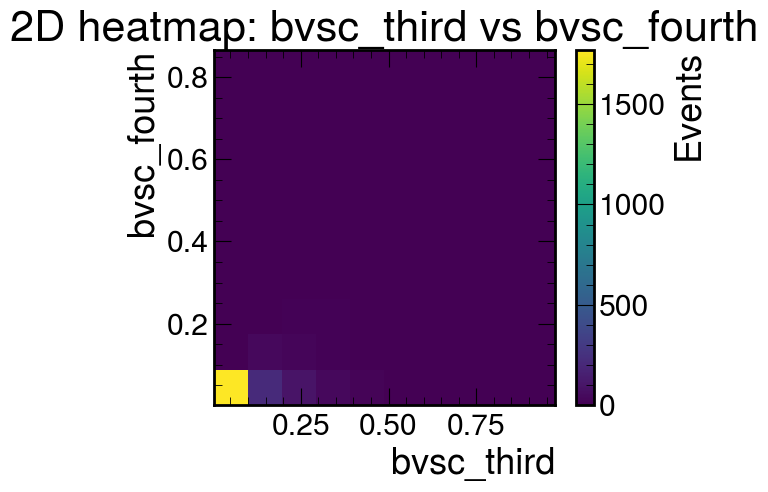

In [ ]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# 선택: mplhep 스타일 (없으면 넘어감)
try:
    import mplhep as hep
    plt.style.use(hep.style.CMS)
except Exception:
    pass

gent = arr["genTtbarId"].to_numpy() % 100

m_bb = np.isin(gent, [51, 52, 53, 54, 55])
m_cc = np.isin(gent, [41, 42, 43, 44, 45])


x = arr["bvsc_third"].to_numpy()
y = arr["bvsc_fourth"].to_numpy()

# (선택) 가중치가 있으면 자동 사용: arr["weight"] 또는 arr.weight
w = None
# for cand in ("weight", "w", "event_weight"):
#     if hasattr(arr, cand) or (hasattr(arr, "fields") and cand in arr.fields):
#         w = get_flat(arr, cand)
#         break

# 유효값 필터
m = np.isfinite(x) & np.isfinite(y) & ~m_bb
if w is not None:
    w = w[m]
else:
    w = np.ones_like(x[m])
x = x[m]; y = y[m]

# --- 히트맵 ---
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# 기본 bins=50. 필요하면 조정하세요.
# range는 데이터 전체 범위(극단치가 많으면 percentile로 좁혀도 됨)
hb = ax.hist2d(x, y, bins=10, weights=w)

cbar = plt.colorbar(hb[3], ax=ax)
cbar.set_label("Events")

ax.set_xlabel("bvsc_third")
ax.set_ylabel("bvsc_fourth")
ax.set_title("2D heatmap: bvsc_third vs bvsc_fourth")

plt.tight_layout()
plt.show()

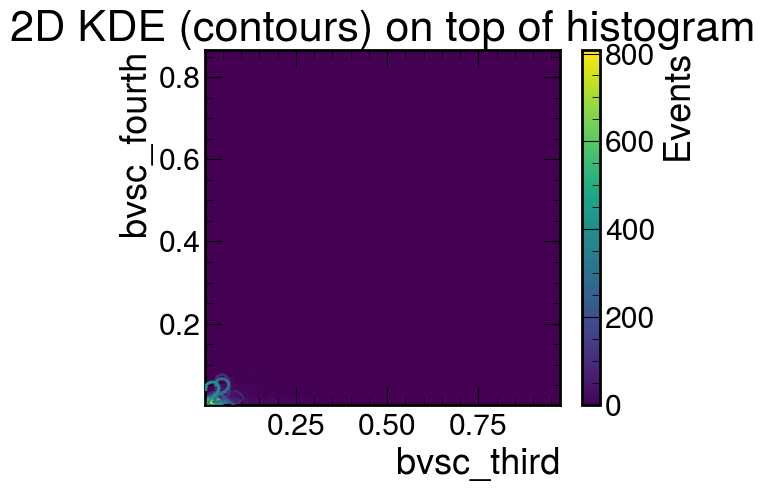

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ---- your pre-processing up to: x, y, w are 1D numpy arrays ----

# Optional: trim extreme tails so the grid focuses where data live
xlo, xhi = np.quantile(x, [0.01, 0.99])
ylo, yhi = np.quantile(y, [0.01, 0.99])

# Grid for evaluating KDE
nx = ny = 150
xx, yy = np.meshgrid(
    np.linspace(xlo, xhi, nx),
    np.linspace(ylo, yhi, ny),
    indexing="xy"
)

# Weighted KDE
from scipy.stats import gaussian_kde
xy = np.vstack([x, y])
kde = gaussian_kde(xy, weights=w, bw_method="scott")  # or "silverman"

# (Optional) tweak bandwidth: <1 sharper, >1 smoother
bw_mul = 0.9
kde.covariance_factor = lambda: bw_mul * kde.scotts_factor()
kde._compute_covariance()

zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)  # density (integrates to 1)

# Convert to "expected counts per pixel" so it’s comparable to hist2d color scale
N = w.sum()
dx = (xhi - xlo) / (nx - 1)
dy = (yhi - ylo) / (ny - 1)
z_counts = zz * N * dx * dy

fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Base heatmap (your current one)
hb = ax.hist2d(x, y, bins=50, weights=w)

# KDE contours overlaid
cs = ax.contour(xx, yy, z_counts, levels=8, linewidths=1.2)
ax.clabel(cs, inline=True, fmt="%.0f")

cbar = plt.colorbar(hb[3], ax=ax)
cbar.set_label("Events")
ax.set_xlabel("bvsc_third")
ax.set_ylabel("bvsc_fourth")
ax.set_title("2D KDE (contours) on top of histogram")

plt.tight_layout()
plt.show()